# Hidden Markov Model for Human Activity Recognition
## Group Project - Formative 2

This notebook implements a Hidden Markov Model to classify human activities (Standing, Walking, Jumping, Still) using accelerometer and gyroscope data from smartphone sensors.

### Background and Motivation

Human Activity Recognition (HAR) is a foundational problem in ubiquitous computing with real-world applications in health monitoring, rehabilitation, sports science, and smart device interaction. Smartphones carry high-quality inertial measurement units (IMUs) that are always available, making them ideal passive sensors for continuous activity monitoring without requiring specialist hardware.

Our unique use case targets **automated wellness monitoring**: by recognising sedentary behaviour (Still/Standing) versus active behaviour (Walking/Jumping) from a single pocket smartphone, a health application could unobtrusively log activity levels throughout the day and flag prolonged inactivity — a risk factor for cardiovascular disease and type 2 diabetes. Hidden Markov Models are particularly well-suited here because they explicitly model the *temporal transitions* between activity states (e.g., the gradual onset of walking from standing), which threshold-based or static classifiers cannot capture.

### Project Overview
- **Activities**: Standing, Walking, Jumping, Still
- **Sensors**: Accelerometer and Gyroscope (x, y, z axes)
- **Device**: iPhone 12 Pro (all group members)
- **Sampling Rate**: 20 ms (50 Hz) — consistent across all recordings
- **Total Recordings**: 120 (30 per activity)

### Group Members

| Name | Device | Sampling Rate | Recordings Contributed |
|------|--------|--------------|----------------------|
| Elissa Twizeyimana | iPhone 12    | 50 Hz | 60 |
| Uwingabire Caline | iPhone 12 Pro | 50 Hz | 60 |

### Task Allocation

| Task | Responsible Member(s) |
|------|-----------------------|
| Data collection & labelling | Elissa Twizeyimana & Uwingabire Caline |
| Feature extraction design | Elissa Twizeyimana & Uwingabire Caline |
| HMM implementation (GaussianHMM class) | Elissa Twizeyimana & Uwingabire Caline |
| Evaluation & visualisations | Elissa Twizeyimana & Uwingabire Caline |
| Report writing | Elissa Twizeyimana & Uwingabire Caline |

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal, stats
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configure Data Path

Choose your environment and set the appropriate data path.

In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set the path to the Data folder in your Google Drive.
# Update this to match your actual folder structure.
base_path = '/content/drive/MyDrive/Colab Notebooks/fommatives/Data'

print(f"Data path set to: {base_path}")

# Verify the data path exists and list activity folders
if os.path.exists(base_path):
    print("Data directory found.")
    activities = ['Jumping', 'Standing', 'Still', 'Walking']
    found_activities = []
    for activity in activities:
        activity_path = os.path.join(base_path, activity)
        if os.path.exists(activity_path):
            found_activities.append(activity)

    if found_activities:
        print(f"Found {len(found_activities)} activity folders: {', '.join(found_activities)}")
    else:
        print(f"Warning: No activity folders found. Expected: {', '.join(activities)}")
else:
    print(f"ERROR: Data directory not found at: {base_path}")
    print("Check your Google Drive folder structure and update base_path above.")


Mounted at /content/drive
Data path set to: /content/drive/MyDrive/Colab Notebooks/fommatives/Data
Data directory found.
Found 4 activity folders: Jumping, Standing, Still, Walking


## 3. Data Loading Functions

In [3]:
def load_sensor_data(activity_path):
    """
    Load accelerometer and gyroscope data from a specific activity recording.
    Robustly handles variable column counts and CSV formats across different
    recording sessions / app versions.
    """
    try:
        accel_raw = pd.read_csv(activity_path / 'Accelerometer.csv')
        gyro_raw  = pd.read_csv(activity_path / 'Gyroscope.csv')

        def standardize_df(df, prefix):
            """Coerce sensor DataFrame to a standard 5-column format."""
            df = df.copy()
            n = df.shape[1]
            if n >= 5:
                df = df.iloc[:, :5]
                df.columns = ['time', 'seconds_elapsed',
                              f'{prefix}_z', f'{prefix}_y', f'{prefix}_x']
            elif n == 4:
                df = df.iloc[:, :4]
                df.columns = ['seconds_elapsed',
                              f'{prefix}_z', f'{prefix}_y', f'{prefix}_x']
                df.insert(0, 'time', df['seconds_elapsed'])
            else:
                return None
            # Force numeric; drop rows with NaN
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            return df.dropna().reset_index(drop=True)

        accel_std = standardize_df(accel_raw, 'accel')
        gyro_std  = standardize_df(gyro_raw,  'gyro')

        if accel_std is None or gyro_std is None:
            print(f"    Skipping {activity_path.name}: unexpected column count "
                  f"(accel={accel_raw.shape[1]}, gyro={gyro_raw.shape[1]})")
            return None

        if len(accel_std) < 30 or len(gyro_std) < 30:
            print(f"    Skipping {activity_path.name}: too few rows after parsing")
            return None

        # Attempt time-based merge; fall back to positional alignment
        merged = pd.merge(accel_std, gyro_std, on=['time', 'seconds_elapsed'])
        if len(merged) < 30:
            min_len = min(len(accel_std), len(gyro_std))
            merged = pd.concat([
                accel_std[['time', 'seconds_elapsed',
                            'accel_z', 'accel_y', 'accel_x']].iloc[:min_len].reset_index(drop=True),
                gyro_std[['gyro_z', 'gyro_y', 'gyro_x']].iloc[:min_len].reset_index(drop=True)
            ], axis=1)

        return merged if len(merged) >= 30 else None

    except Exception as e:
        print(f"    Error loading {activity_path.name}: {e}")
        return None


def load_all_data(base_path):
    """
    Load all activity data from the dataset.
    """
    base_path = Path(base_path)
    activities = ['Jumping', 'Standing', 'Still', 'Walking']
    all_data = []

    for activity in activities:
        activity_path = base_path / activity
        if not activity_path.exists():
            print(f"  Warning: {activity} folder not found at {activity_path}")
            continue

        loaded = 0
        for session_path in sorted(activity_path.iterdir()):
            if session_path.is_dir():
                if (session_path / 'Accelerometer.csv').exists():
                    data = load_sensor_data(session_path)
                    if data is not None and len(data) > 0:
                        all_data.append({
                            'activity': activity,
                            'session': session_path.name,
                            'data': data
                        })
                        loaded += 1
                else:
                    print(f"    No Accelerometer.csv in {activity}/{session_path.name}")
        print(f"  {activity}: {loaded} recordings loaded")

    return all_data


# Load all data using the configured base_path from the configuration cell above
all_recordings = load_all_data(base_path)

print(f"\nTotal recordings loaded: {len(all_recordings)}")
print("\nRecordings per activity:")
activity_counts = {}
for recording in all_recordings:
    activity = recording['activity']
    activity_counts[activity] = activity_counts.get(activity, 0) + 1

for activity, count in sorted(activity_counts.items()):
    print(f"  {activity}: {count} recordings")


  Jumping: 30 recordings loaded
  Standing: 30 recordings loaded
  Still: 30 recordings loaded
  Walking: 30 recordings loaded

Total recordings loaded: 120

Recordings per activity:
  Jumping: 30 recordings
  Standing: 30 recordings
  Still: 30 recordings
  Walking: 30 recordings


### Visualize Sample Data

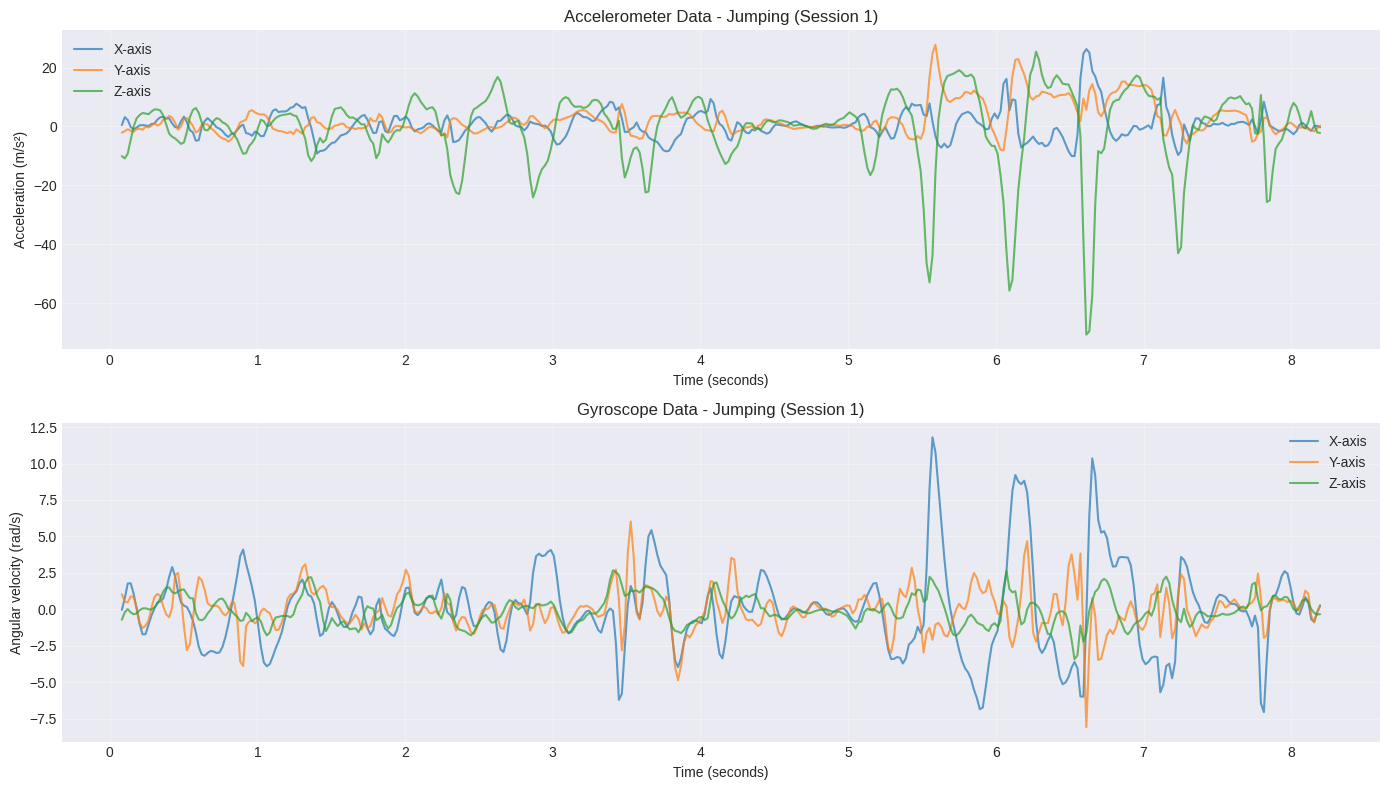

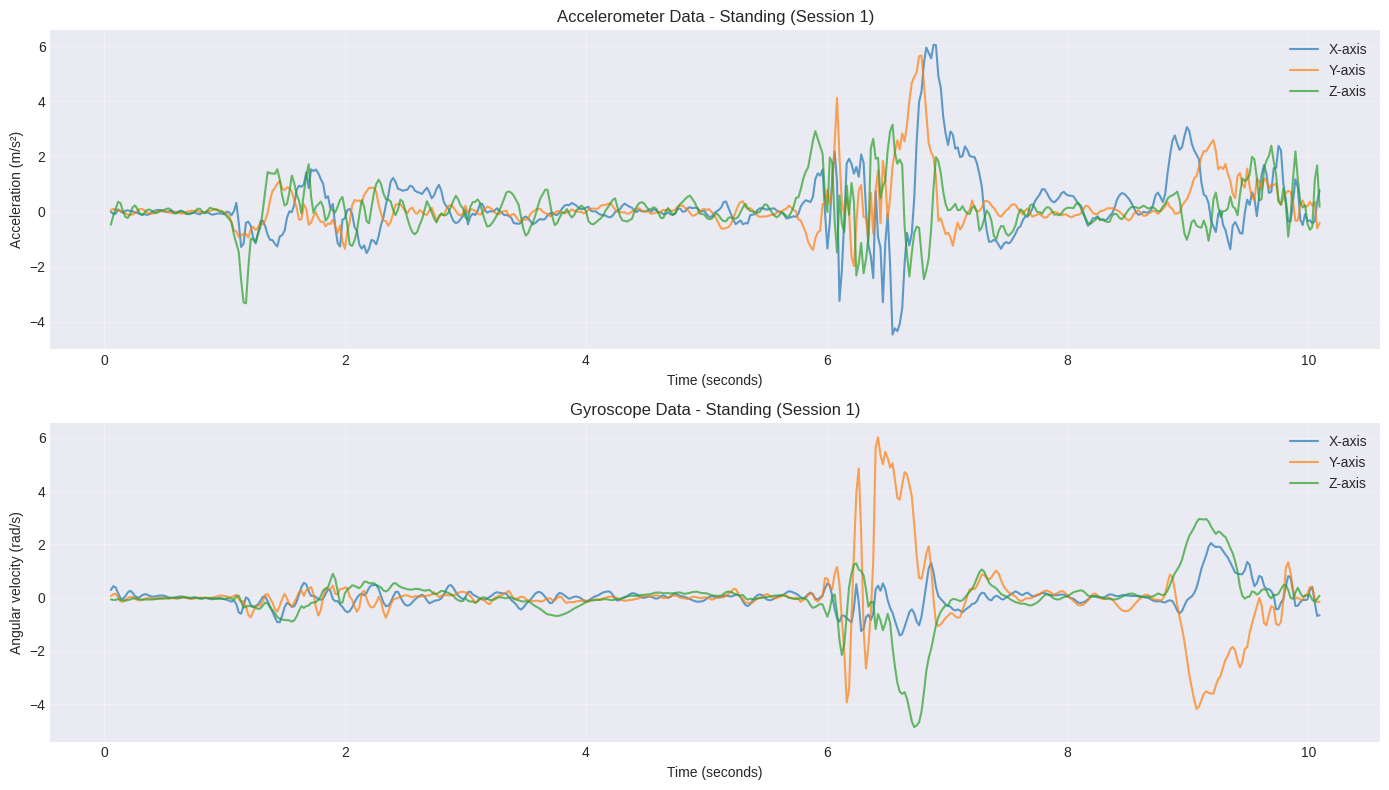

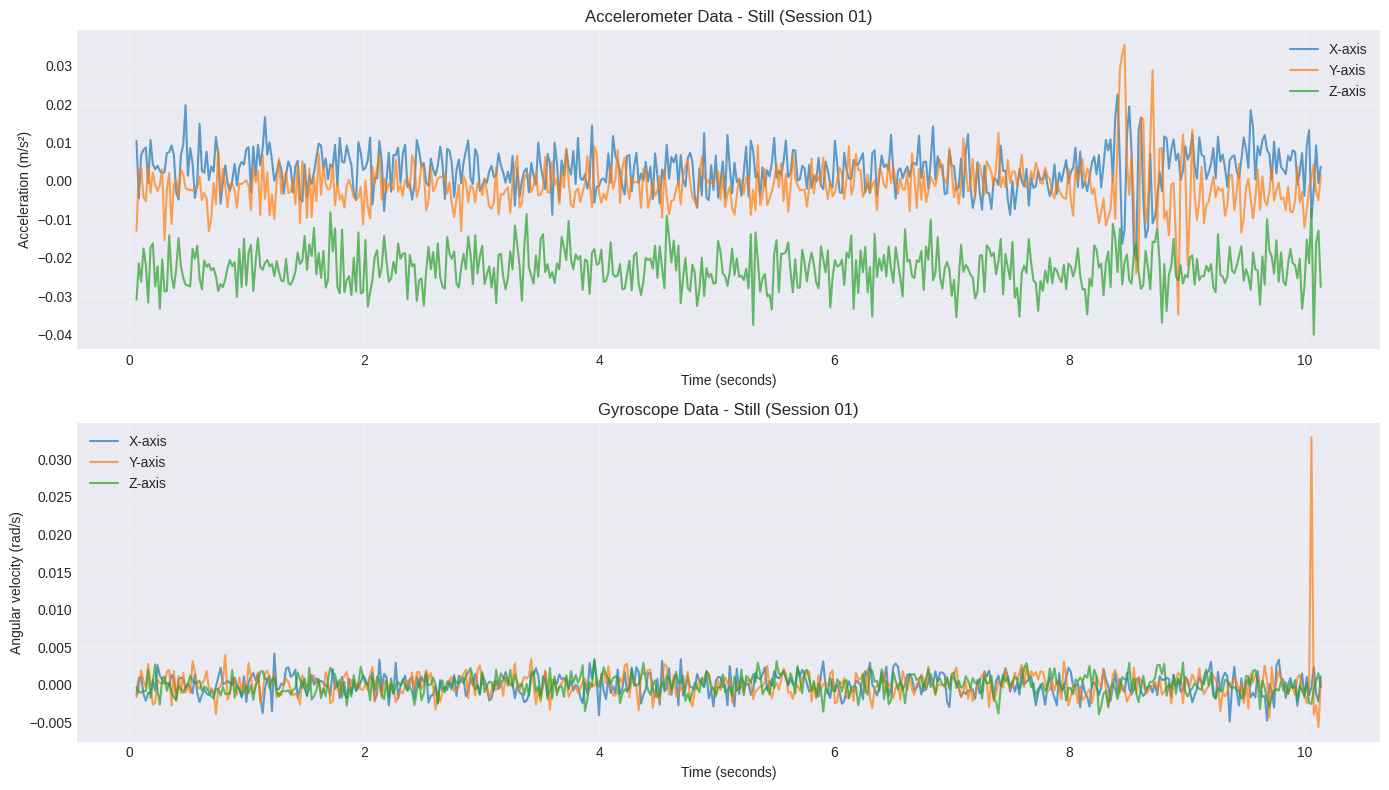

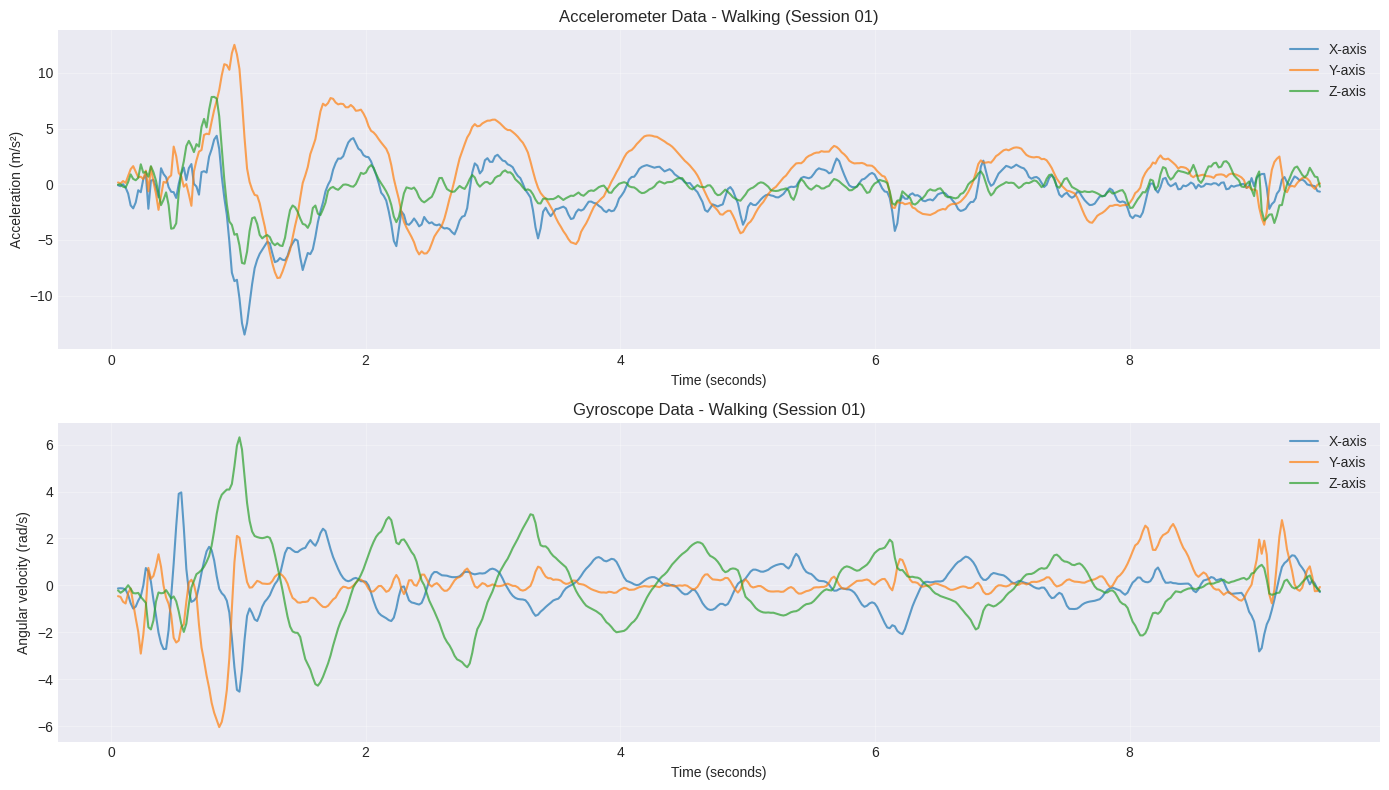

In [4]:
def plot_sample_recording(recording_dict):
    """
    Visualize accelerometer and gyroscope data for a single recording.
    """
    data = recording_dict['data']
    activity = recording_dict['activity']
    session = recording_dict['session']

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot accelerometer data
    axes[0].plot(data['seconds_elapsed'], data['accel_x'], label='X-axis', alpha=0.7)
    axes[0].plot(data['seconds_elapsed'], data['accel_y'], label='Y-axis', alpha=0.7)
    axes[0].plot(data['seconds_elapsed'], data['accel_z'], label='Z-axis', alpha=0.7)
    axes[0].set_xlabel('Time (seconds)')
    axes[0].set_ylabel('Acceleration (m/s²)')
    axes[0].set_title(f'Accelerometer Data - {activity} (Session {session})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot gyroscope data
    axes[1].plot(data['seconds_elapsed'], data['gyro_x'], label='X-axis', alpha=0.7)
    axes[1].plot(data['seconds_elapsed'], data['gyro_y'], label='Y-axis', alpha=0.7)
    axes[1].plot(data['seconds_elapsed'], data['gyro_z'], label='Z-axis', alpha=0.7)
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_ylabel('Angular velocity (rad/s)')
    axes[1].set_title(f'Gyroscope Data - {activity} (Session {session})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Plot one sample from each activity
activities = ['Jumping', 'Standing', 'Still', 'Walking']
for activity in activities:
    # Find first recording of this activity
    for recording in all_recordings:
        if recording['activity'] == activity:
            plot_sample_recording(recording)
            break